# Data Loading & Preprocessing for Sleep-Inspired Batch Learning

## Why these datasets?

These two datasets give us a useful contrast for the later experiment:

- Iris is small and fast, so it is ideal for validating the learning schedule logic quickly.
- Digits is more image-like and has more classes, which makes it a better stress test than Iris while still remaining lightweight.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

I0000 00:00:1777415892.161184  900717 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777415892.171724  900717 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777415893.114616  900717 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777415896.758519  900717 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 1) Load the datasets

In [2]:
iris = load_iris(as_frame=True)
digits = load_digits()

# Iris
X_iris = iris.data.copy()
y_iris = iris.target.copy()

# Digits
X_digits = digits.data.copy()
y_digits = digits.target.copy()
images_digits = digits.images.copy()

print("Iris feature matrix shape:", X_iris.shape)
print("Iris target shape:", y_iris.shape)
print("Digits feature matrix shape:", X_digits.shape)
print("Digits image tensor shape:", images_digits.shape)
print("Digits target shape:", y_digits.shape)

Iris feature matrix shape: (150, 4)
Iris target shape: (150,)
Digits feature matrix shape: (1797, 64)
Digits image tensor shape: (1797, 8, 8)
Digits target shape: (1797,)


## 2) Initial inspection

checking dataset size and dimensionality, feature dtypes, missing values, basic class balance

In [3]:
def summarize_class_distribution(y, class_names=None):
    counts = pd.Series(y).value_counts().sort_index()
    if class_names is not None:
        counts.index = [class_names[i] for i in counts.index]
    proportions = (counts / counts.sum()).round(3)
    return pd.DataFrame({"count": counts, "proportion": proportions})

print("Iris dtypes:")
display(X_iris.dtypes.to_frame("dtype"))

print("Iris missing values per column:")
display(X_iris.isna().sum().to_frame("missing_count"))

print("Iris class distribution:")
display(summarize_class_distribution(y_iris, iris.target_names))

digits_df = pd.DataFrame(X_digits)
print("Digits missing values (total):", int(digits_df.isna().sum().sum()))
print("\nDigits class distribution:")
display(summarize_class_distribution(y_digits, [str(i) for i in digits.target_names]))

Iris dtypes:


,dtype
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64


Iris missing values per column:


,missing_count
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


Iris class distribution:


,count,proportion
setosa,50,0.333
versicolor,50,0.333
virginica,50,0.333


Digits missing values (total): 0

Digits class distribution:


,count,proportion
0,178,0.099
1,182,0.101
2,177,0.098
3,183,0.102
4,181,0.101
5,182,0.101
6,181,0.101
7,179,0.100
8,174,0.097
9,180,0.100


### Observation

- No missing values in either dataset, so no imputation.
- Both problems are multiclass classification.
- Class balance is good so we can use stratified splitting for label proportions across train/validation/test sets

## 3) Visual sanity check for the image dataset

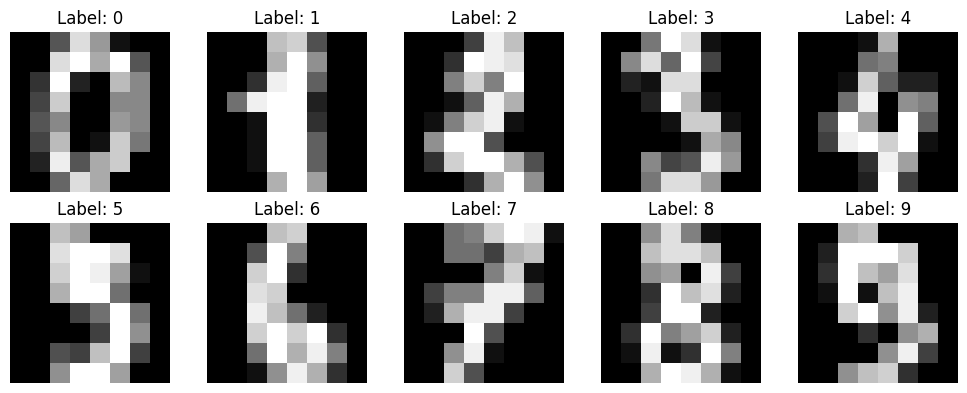

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(images_digits[idx], cmap="gray")
    ax.set_title(f"Label: {y_digits[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4) Split the data

We created train, validation, and test splits for both datasets

We use stratified sampling so each split keeps roughly the same class distribution as the full dataset

In [5]:
def stratified_train_val_test_split(X, y, test_size=0.2, val_size=0.2, random_state=42):
    '''
    Splits data into train / validation / test using stratification
    val_size is interpreted as a fraction of the full dataset
    '''
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    adjusted_val_size = val_size / (1 - test_size)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=adjusted_val_size,
        stratify=y_train_val,
        random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [6]:
X_iris_train, X_iris_val, X_iris_test, y_iris_train, y_iris_val, y_iris_test = stratified_train_val_test_split(
    X_iris, y_iris, test_size=0.2, val_size=0.2, random_state=RANDOM_STATE
)

X_digits_train, X_digits_val, X_digits_test, y_digits_train, y_digits_val, y_digits_test = stratified_train_val_test_split(
    X_digits, y_digits, test_size=0.2, val_size=0.2, random_state=RANDOM_STATE
)

print("Iris split sizes:")
print("  train:", X_iris_train.shape, y_iris_train.shape)
print("  val:  ", X_iris_val.shape, y_iris_val.shape)
print("  test: ", X_iris_test.shape, y_iris_test.shape)

print("\nDigits split sizes:")
print("  train:", X_digits_train.shape, y_digits_train.shape)
print("  val:  ", X_digits_val.shape, y_digits_val.shape)
print("  test: ", X_digits_test.shape, y_digits_test.shape)

Iris split sizes:
  train: (90, 4) (90,)
  val:   (30, 4) (30,)
  test:  (30, 4) (30,)

Digits split sizes:
  train: (1077, 64) (1077,)
  val:   (360, 64) (360,)
  test:  (360, 64) (360,)


## 5) Preprocess Iris

Technique used: standardization

For the Iris features, we applied z-score standardization

This is a good default for tabular neural-network inputs because:

- the features are continuous and measured on different scales
- gradient-based models usually train more smoothly when features are centered and scaled
- it prevents a larger-scale feature from dominating the optimization process

In [7]:
iris_scaler = StandardScaler()

X_iris_train_scaled = iris_scaler.fit_transform(X_iris_train)
X_iris_val_scaled = iris_scaler.transform(X_iris_val)
X_iris_test_scaled = iris_scaler.transform(X_iris_test)

print("Iris train mean after scaling (approx. 0):")
print(np.round(X_iris_train_scaled.mean(axis=0), 6))
print("\nIris train std after scaling (approx. 1):")
print(np.round(X_iris_train_scaled.std(axis=0), 6))

Iris train mean after scaling (approx. 0):
[ 0. -0. -0. -0.]

Iris train std after scaling (approx. 1):
[1. 1. 1. 1.]


## 6) Preprocess Digits

did intensity normalization to [0, 1]
The digits dataset stores pixel intensities on a bounded scale from 0 to 16
scaled intensities into [0, 1]:

transformation after splitting

In [8]:
X_digits_train_scaled = X_digits_train.astype(np.float32) / 16.0
X_digits_val_scaled = X_digits_val.astype(np.float32) / 16.0
X_digits_test_scaled = X_digits_test.astype(np.float32) / 16.0

print("Digits value range after scaling:")
print("  train:", (X_digits_train_scaled.min(), X_digits_train_scaled.max()))
print("  val:  ", (X_digits_val_scaled.min(), X_digits_val_scaled.max()))
print("  test: ", (X_digits_test_scaled.min(), X_digits_test_scaled.max()))

Digits value range after scaling:
  train: (np.float32(0.0), np.float32(1.0))
  val:   (np.float32(0.0), np.float32(1.0))
  test:  (np.float32(0.0), np.float32(1.0))


## 7) Final model-ready objects

storing the preprocessed datasets in a consistent dictionary format

In [9]:
prepared_data = {
    "iris": {
        "X_train": X_iris_train_scaled.astype(np.float32),
        "X_val": X_iris_val_scaled.astype(np.float32),
        "X_test": X_iris_test_scaled.astype(np.float32),
        "y_train": np.asarray(y_iris_train, dtype=np.int64),
        "y_val": np.asarray(y_iris_val, dtype=np.int64),
        "y_test": np.asarray(y_iris_test, dtype=np.int64),
        "feature_names": iris.feature_names,
        "class_names": list(iris.target_names),
        "preprocessing": {
            "input_scaling": "StandardScaler fitted on training data only",
            "label_encoding": "none needed; labels already integer-coded",
            "feature_selection": "not applied"
        }
    },
    "digits": {
        "X_train": X_digits_train_scaled.astype(np.float32),
        "X_val": X_digits_val_scaled.astype(np.float32),
        "X_test": X_digits_test_scaled.astype(np.float32),
        "y_train": np.asarray(y_digits_train, dtype=np.int64),
        "y_val": np.asarray(y_digits_val, dtype=np.int64),
        "y_test": np.asarray(y_digits_test, dtype=np.int64),
        "input_shape_dense": (X_digits_train_scaled.shape[1],),
        "input_shape_image": (8, 8),
        "class_names": [str(i) for i in digits.target_names],
        "preprocessing": {
            "input_scaling": "pixel intensities divided by 16 to map into [0, 1]",
            "label_encoding": "none needed; labels already integer-coded",
            "feature_selection": "not applied"
        }
    }
}

for dataset_name, payload in prepared_data.items():
    print(dataset_name.upper())
    print("  X_train:", payload["X_train"].shape, payload["X_train"].dtype)
    print("  y_train:", payload["y_train"].shape, payload["y_train"].dtype)
    print("  preprocessing:", payload["preprocessing"])
    print()

IRIS
  X_train: (90, 4) float32
  y_train: (90,) int64
  preprocessing: {'input_scaling': 'StandardScaler fitted on training data only', 'label_encoding': 'none needed; labels already integer-coded', 'feature_selection': 'not applied'}

DIGITS
  X_train: (1077, 64) float32
  y_train: (1077,) int64
  preprocessing: {'input_scaling': 'pixel intensities divided by 16 to map into [0, 1]', 'label_encoding': 'none needed; labels already integer-coded', 'feature_selection': 'not applied'}



# Model and Training

In [21]:
def symmetric_batch_schedule(base, depth): 
	seq = [base] 
	for d in range(1, depth + 1):
		seq = seq + [base * 2**d] + seq[::-1] 
	return np.array(seq)

In [70]:
def evaluate_model(model, dataset_payload, history=None, batch_sizes=None):
    X_test = np.asarray(dataset_payload["X_test"], dtype=np.float32)
    y_test = dataset_payload["y_test"]
    class_names = dataset_payload["class_names"]

    y_pred_probs = model(X_test, training=False).numpy()
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    if history is None:
        history = getattr(model, "history", None)

    history_series = {"loss": [], "val_loss": []}
    history_items = history if isinstance(history, (list, tuple)) else [history] if history is not None else []
    for item in history_items:
        item_dict = getattr(item, "history", item)
        if not item_dict:
            continue
        history_series["loss"].extend(item_dict.get("loss", []))
        history_series["val_loss"].extend(item_dict.get("val_loss", []))

    if history_series["loss"]:
        epochs = np.arange(1, len(history_series["loss"]) + 1)

        if batch_sizes is not None:
            batch_sizes = np.asarray(batch_sizes).reshape(-1)
            if batch_sizes.size == 1:
                batch_sizes = np.repeat(int(batch_sizes.item()), len(epochs))
            elif batch_sizes.size != len(epochs):
                batch_sizes = np.resize(batch_sizes, len(epochs))

        fig, ax_loss = plt.subplots(figsize=(8, 6))
        ax_loss.plot(epochs, history_series["loss"], label="train_loss", color="tab:blue")
        if history_series["val_loss"]:
            ax_loss.plot(epochs, history_series["val_loss"], label="val_loss", color="tab:orange")
        ax_loss.set_title("Model Loss")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")

        handles, labels = ax_loss.get_legend_handles_labels()

        if batch_sizes is not None:
            ax_batch = ax_loss.twinx()
            ax_batch.step(epochs, batch_sizes, where="mid", label="batch_size", color="tab:green", alpha=0.35, linewidth=2)
            ax_batch.scatter(epochs, batch_sizes, color="tab:green", alpha=0.35, s=18)
            ax_batch.set_ylabel("Batch size")
            batch_handles, batch_labels = ax_batch.get_legend_handles_labels()
            handles += batch_handles
            labels += batch_labels

        ax_loss.legend(handles, labels, loc="best")
        plt.tight_layout()
        plt.show()

## Iris Model

In [42]:
iris_sleep_model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(4,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax")
])

iris_sleep_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


iris_reg_model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(4,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax")
])

iris_reg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

iris_prep = prepared_data["iris"]

/home/ottenl/classwork/CSC5611/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
batch_schedule = symmetric_batch_schedule(base=4, depth=4)
iris_sleep_histories = []

for epoch, bs in enumerate(batch_schedule):
    print(f"\nEpoch {epoch+1}, batch_size={bs}")

    iris_sleep_history = iris_sleep_model.fit(
        iris_prep["X_train"],
        iris_prep["y_train"],
        validation_data=(iris_prep["X_val"], iris_prep["y_val"]),
        epochs=1,
        batch_size=bs,
        shuffle=True,
        verbose=1
    )
    iris_sleep_histories.append(iris_sleep_history)


Epoch 1, batch_size=4
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9889 - loss: 0.0579 - val_accuracy: 0.8667 - val_loss: 0.2740

Epoch 2, batch_size=8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9778 - loss: 0.0495 - val_accuracy: 0.9000 - val_loss: 0.2840

Epoch 3, batch_size=4
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9778 - loss: 0.0535 - val_accuracy: 0.9000 - val_loss: 0.2708

Epoch 4, batch_size=16
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9889 - loss: 0.0459 - val_accuracy: 0.9000 - val_loss: 0.2818

Epoch 5, batch_size=4
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9889 - loss: 0.0475 - val_accuracy: 0.9333 - val_loss: 0.2651

Epoch 6, batch_size=8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9778 - loss: 0.0437 - val_accuracy: 0.9000 - val_loss: 0.2531

Epoch 7, batch_size=4
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9778 - loss: 0.0443 - val_accuracy: 0.9000 - val_loss: 0.2645

Epoch 8, batch_size=32
3/3 ━━━

In [54]:
iris_reg_history = iris_reg_model.fit(
    iris_prep["X_train"],
    iris_prep["y_train"],
    validation_data=(iris_prep["X_val"], iris_prep["y_val"]),
    epochs=len(batch_schedule),
    batch_size=batch_schedule.mean().astype(int),
    shuffle=True,
    verbose=1
    )

Epoch 1/31
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9778 - loss: 0.0652 - val_accuracy: 0.8667 - val_loss: 0.3042
Epoch 2/31
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9778 - loss: 0.0637 - val_accuracy: 0.8667 - val_loss: 0.3045
Epoch 3/31
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9778 - loss: 0.0603 - val_accuracy: 0.8667 - val_loss: 0.2991
Epoch 4/31
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9778 - loss: 0.0583 - val_accuracy: 0.8667 - val_loss: 0.2950
Epoch 5/31
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9778 - loss: 0.0595 - val_accuracy: 0.9000 - val_loss: 0.2880
Epoch 6/31
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9778 - loss: 0.0555 - val_accuracy: 0.8667 - val_loss: 0.2915
Epoch 7/31
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9778 - loss: 0.0536 - val_accuracy: 0.8667 - val_loss: 0.2903
Epoch 8/31
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9778 - loss: 0.0538 - val_accuracy: 0.8667 - val_loss: 0.2853


Accuracy: 0.9333333333333333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


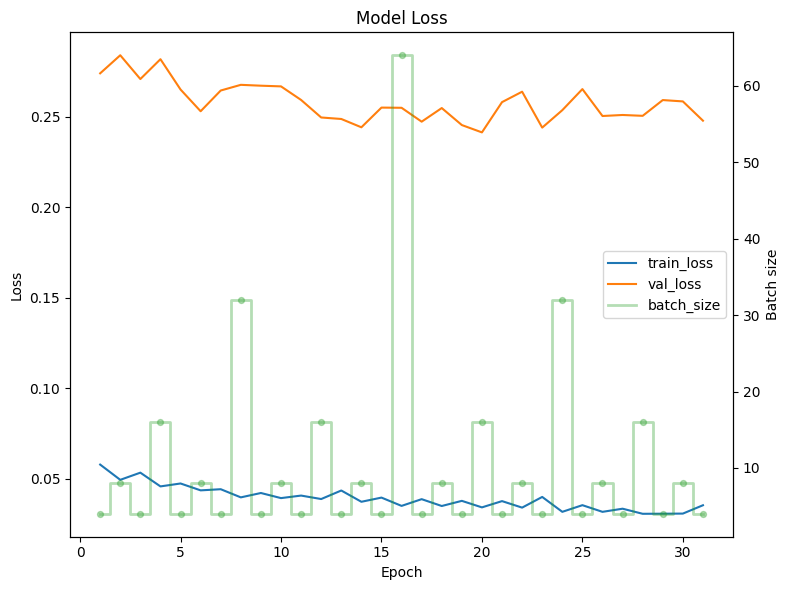

In [71]:
evaluate_model(iris_sleep_model, iris_prep, iris_sleep_histories, batch_schedule)

Accuracy: 0.9333333333333333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


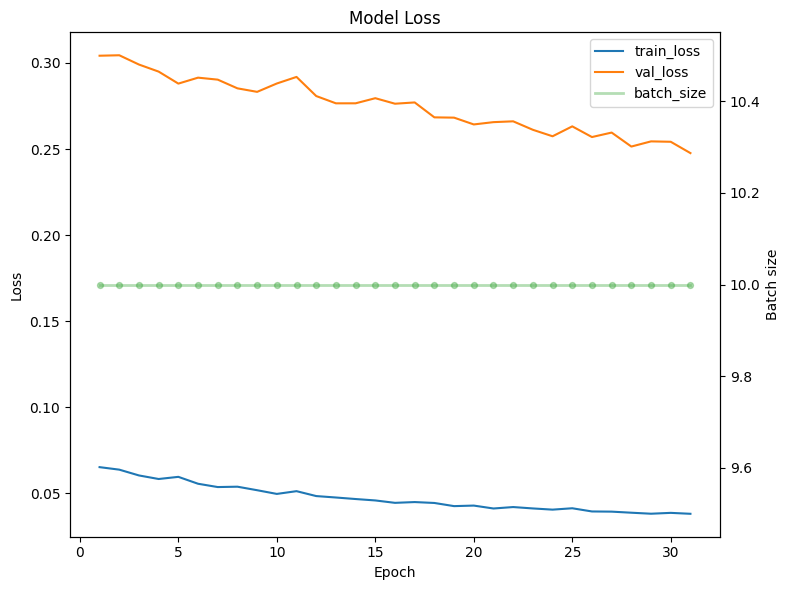

In [72]:
evaluate_model(iris_reg_model, iris_prep, iris_reg_history, int(batch_schedule.mean()))

## Digits Model

In [60]:
digits_sleep_model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(64,)),
    layers.Dense(32, activation="relu", input_shape=(64,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

digits_sleep_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

digits_reg_model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(64,)),
    layers.Dense(32, activation="relu", input_shape=(64,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

digits_reg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

digits_prep = prepared_data["digits"]

/home/ottenl/classwork/CSC5611/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
batch_schedule = symmetric_batch_schedule(base=4, depth=4)
digits_sleep_histories = []

for epoch, bs in enumerate(batch_schedule):
    print(f"\nEpoch {epoch+1}, batch_size={bs}")

    digits_sleep_history = digits_sleep_model.fit(
        digits_prep["X_train"],
        digits_prep["y_train"],
        validation_data=(digits_prep["X_val"], digits_prep["y_val"]),
        epochs=1,
        batch_size=bs,
        shuffle=True,
        verbose=1
    )
    digits_sleep_histories.append(digits_sleep_history)


Epoch 1, batch_size=4
  1/270 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 1.0000 - loss: 0.0717

270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0699 - val_accuracy: 0.9611 - val_loss: 0.1199

Epoch 2, batch_size=8
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9926 - loss: 0.0379 - val_accuracy: 0.9722 - val_loss: 0.0875

Epoch 3, batch_size=4
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9749 - loss: 0.0740 - val_accuracy: 0.9444 - val_loss: 0.1723

Epoch 4, batch_size=16
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9972 - loss: 0.0260 - val_accuracy: 0.9611 - val_loss: 0.0944

Epoch 5, batch_size=4
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0327 - val_accuracy: 0.9639 - val_loss: 0.1332

Epoch 6, batch_size=8
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9954 - loss: 0.0214 - val_accuracy: 0.9611 - val_loss: 0.1477

Epoch 7, batch_size=4
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9963 - loss: 0.0228 - val_accuracy: 0.9778 - val_loss: 0.0966

Epoch 8, batch_size=32
34/34 ━━━━━━━━━━━━━━

In [67]:
digits_reg_history = digits_reg_model.fit(
    digits_prep["X_train"],
    digits_prep["y_train"],
    validation_data=(digits_prep["X_val"], digits_prep["y_val"]),
    epochs=len(batch_schedule),
    batch_size=batch_schedule.mean().astype(int),
    shuffle=True,
    verbose=1
    )

Epoch 1/31
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9879 - loss: 0.0600 - val_accuracy: 0.9472 - val_loss: 0.1345
Epoch 2/31
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9870 - loss: 0.0510 - val_accuracy: 0.9694 - val_loss: 0.1496
Epoch 3/31
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9898 - loss: 0.0411 - val_accuracy: 0.9583 - val_loss: 0.1448
Epoch 4/31
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9898 - loss: 0.0444 - val_accuracy: 0.9667 - val_loss: 0.1123
Epoch 5/31
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9926 - loss: 0.0323 - val_accuracy: 0.9444 - val_loss: 0.1457
Epoch 6/31
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9907 - loss: 0.0324 - val_accuracy: 0.9722 - val_loss: 0.0928
Epoch 7/31
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9963 - loss: 0.0228 - val_accuracy: 0.9611 - val_loss: 0.1071
Epoch 8/31
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9907 - loss: 0.0309 - val_accuracy: 0.

Accuracy: 0.975

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.94      0.93        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      0.97      0.99        37
           6       0.95      1.00      0.97        36
           7       0.97      1.00      0.99        36
           8       0.97      0.91      0.94        35
           9       0.97      0.92      0.94        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360


Confusion matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0  2  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 

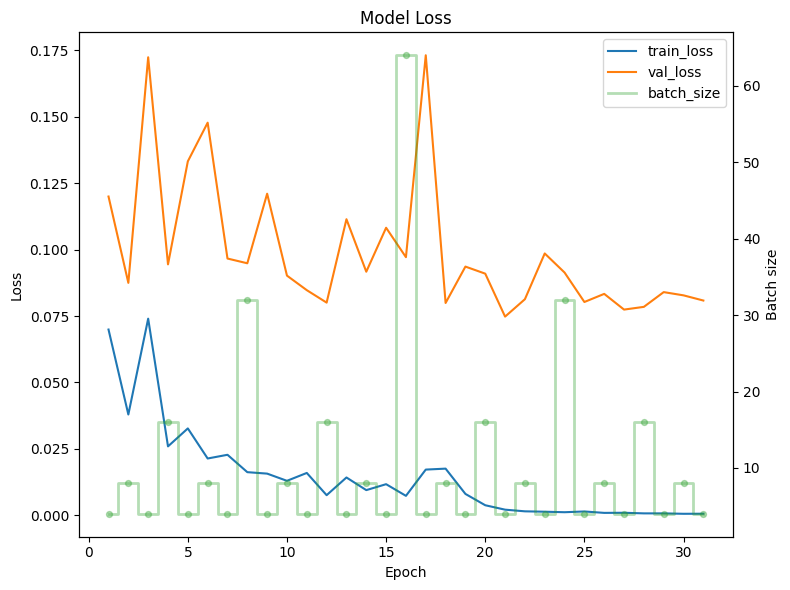

In [73]:
evaluate_model(digits_sleep_model, digits_prep, digits_sleep_histories, batch_schedule)

Accuracy: 0.9638888888888889

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        36
           1       0.89      0.94      0.92        36
           2       0.97      1.00      0.99        35
           3       1.00      0.95      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.86      0.90        35
           9       0.95      0.97      0.96        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360


Confusion matrix:
[[34  0  1  0  1  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  1  1]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 35  0  1  0  0  0  1]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0

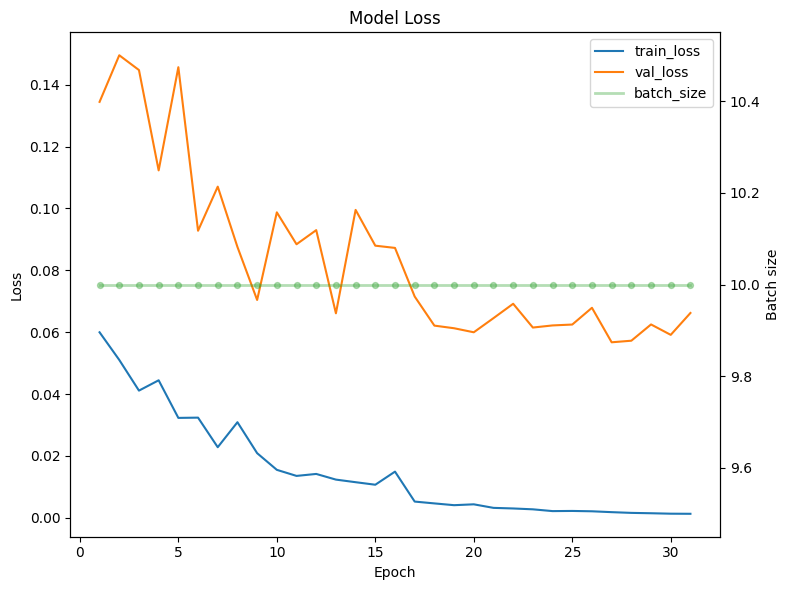

In [74]:
evaluate_model(digits_reg_model, digits_prep, digits_reg_history, int(batch_schedule.mean()))

## LeNet

In [ ]:
# https://www.kaggle.com/code/mustafacicek/mnist-lenet-5-implementation-on-keras
lenet5 = keras.Sequential(
    [
        keras.layers.Conv2D(filters = 6, kernel_size = (5, 5), strides = (1, 1), activation = "tanh", input_shape = (8, 8, 1)),
        keras.layers.AveragePooling2D(pool_size = (2, 2)),
        keras.layers.Conv2D(filters = 16, kernel_size = (5, 5), strides = (1, 1), activation = "tanh"),
        keras.layers.AveragePooling2D(pool_size = (2, 2), strides = 2),
        
        keras.layers.Flatten(),
        keras.layers.Dense(units = 120, activation = "tanh"),
        keras.layers.Dense(units = 84, activation = "tanh"),
        keras.layers.Dense(units = 10, activation = "softmax")
    ]
)

lenet5_sleep = lenet5.copy()

X_digits_train_image = digits_prep["X_train"].reshape(-1, 8, 8, 1)
X_digits_val_image   = digits_prep["X_val"].reshape(-1, 8, 8, 1)
X_digits_test_image  = digits_prep["X_test"].reshape(-1, 8, 8, 1)

NameError: name 'input_shape' is not defined

In [ ]:
for epoch, bs in enumerate(batch_schedule):
    print(f"\nEpoch {epoch+1}, batch_size={bs}")

    digits_sleep_history = digits_sleep_model.fit(
        X_digits_train_image,
        digits_prep["y_train"],
        validation_data=(X_digits_val_image, digits_prep["y_val"]),
        epochs=1,
        batch_size=bs,
        shuffle=True,
        verbose=1
    )
    digits_sleep_histories.append(digits_sleep_history)